In [1]:
from google.colab import files
uploaded = files.upload()

Saving bluestock_mf.db to bluestock_mf (1).db


# Importing modules and DB Connection

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
import plotly.graph_objects as go
import plotly.express as px
from plotly.subplots import make_subplots
import scipy.stats as stats
import sqlite3, os
import warnings
warnings.filterwarnings('ignore')

# ── Style ──────────────────────────────────────────────
plt.rcParams['figure.figsize'] = (14, 6)
plt.rcParams['font.family'] = 'DejaVu Sans'
sns.set_theme(style='whitegrid', palette='muted')

# ── DB connection ──────────────────────────────────────
DB_PATH = 'bluestock_mf.db'
conn = sqlite3.connect(DB_PATH)

def con():
    return sqlite3.connect(DB_PATH)

CHARTS_DIR = 'reports/charts'
os.makedirs(CHARTS_DIR, exist_ok=True)

print("Connected to database")

Connected to database


# Loading NAV and benchmark data

In [3]:
with con() as c:
    df_check = pd.read_sql("SELECT * FROM benchmark_indices LIMIT 2", c)
print(df_check.columns.tolist())
print(df_check)

['date', 'index_name', 'close_value']
         date index_name  close_value
0  03-01-2022    NIFTY50     17492.79
1  04-01-2022    NIFTY50     17689.64


In [4]:
# ── Load NAV history ───────────────────────────────────
nav_df = pd.read_sql("""
    SELECT n.amfi_code, n.date, n.nav, d.scheme_name, d.category,
           d.fund_house, d.expense_ratio_pct
    FROM fact_nav n
    JOIN dim_fund d ON n.amfi_code = d.amfi_code
    ORDER BY n.amfi_code, n.date
""", conn)

nav_df['date'] = pd.to_datetime(nav_df['date'])
nav_df = nav_df.sort_values(['amfi_code', 'date']).reset_index(drop=True)

# ── Load benchmark (Nifty 50 & Nifty 100) ─────────────
bench_df = pd.read_sql("""
    SELECT date, index_name, close_value
    FROM benchmark_indices
    WHERE index_name IN ('Nifty 50', 'Nifty 100')
    ORDER BY index_name, date
""", conn)

bench_df['date'] = pd.to_datetime(bench_df['date'])

print(f"NAV rows loaded      : {len(nav_df):,}")
print(f"Unique funds         : {nav_df['amfi_code'].nunique()}")
print(f"Date range           : {nav_df['date'].min().date()} → {nav_df['date'].max().date()}")
print(f"Benchmark rows       : {len(bench_df):,}")
print(f"Indices available    : {bench_df['index_name'].unique()}")

NAV rows loaded      : 46,000
Unique funds         : 40
Date range           : 2022-01-03 → 2026-05-29
Benchmark rows       : 0
Indices available    : []


# Daily returns with validation

── Daily Return Distribution Validation ──
  Mean   : 0.0631%
  Std    : 1.0290%
  Min    : -5.8102%
  Max    : 6.4713%
  Nulls  : 40

 Extreme daily moves (>10%): 0 rows


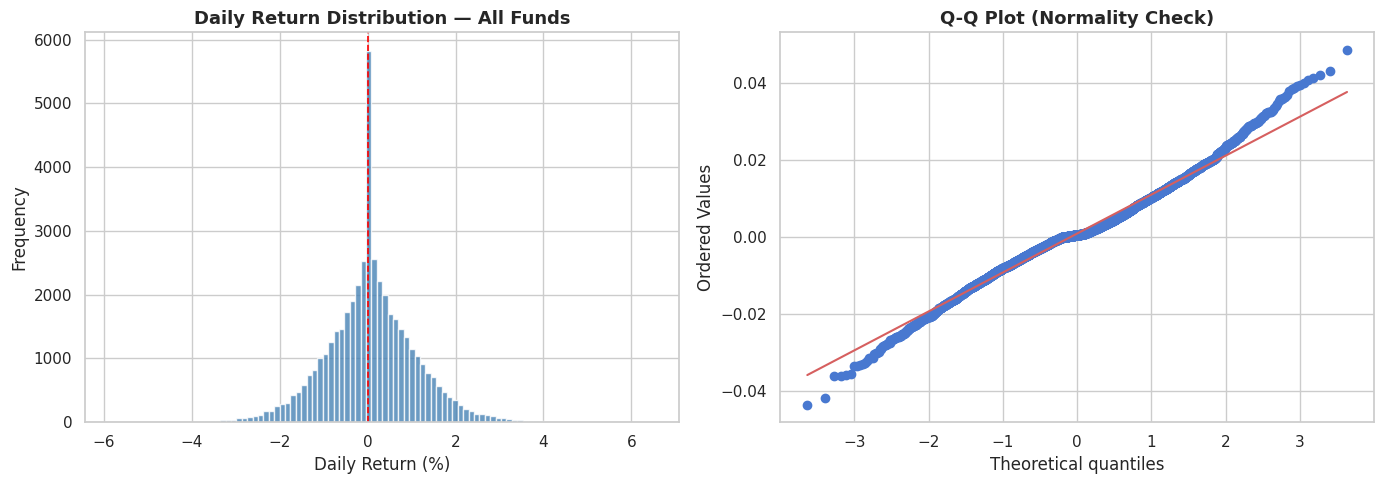

Chart saved


In [30]:
# ── Compute daily returns for every fund ───────────────
nav_df['daily_return'] = (
    nav_df.groupby('amfi_code')['nav'].pct_change()          # nav_t / nav_t-1 − 1
)

# ── Validation ─────────────────────────────────────────
ret_stats = nav_df['daily_return'].dropna()

print("── Daily Return Distribution Validation ──")
print(f"  Mean   : {ret_stats.mean()*100:.4f}%")
print(f"  Std    : {ret_stats.std()*100:.4f}%")
print(f"  Min    : {ret_stats.min()*100:.4f}%")
print(f"  Max    : {ret_stats.max()*100:.4f}%")
print(f"  Nulls  : {nav_df['daily_return'].isna().sum()}")

# ── Sanity check — flag extreme outliers (>10% single day) ──
extremes = nav_df[nav_df['daily_return'].abs() > 0.10]
print(f"\n Extreme daily moves (>10%): {len(extremes)} rows")
if len(extremes) > 0:
    print(extremes[['amfi_code','scheme_name','date','nav','daily_return']].head(10))

# ── Histogram ──────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(ret_stats * 100, bins=100, color='steelblue', edgecolor='white', alpha=0.8)
axes[0].axvline(0, color='red', linestyle='--', linewidth=1.2)
axes[0].set_title('Daily Return Distribution — All Funds', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Daily Return (%)')
axes[0].set_ylabel('Frequency')

# Q-Q plot to check normality
stats.probplot(ret_stats.sample(min(5000, len(ret_stats)), random_state=42),
               dist="norm", plot=axes[1])
axes[1].set_title('Q-Q Plot (Normality Check)', fontsize=13, fontweight='bold')

plt.tight_layout()
plt.savefig('reports/charts/daily_return_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart saved")

# CAGR Computation

In [6]:
def compute_cagr(group, years):
    """
    CAGR = (NAV_end / NAV_start) ^ (1/n) − 1
    Looks back exactly `years` years from the latest date in the group.
    Returns NaN if not enough history.
    """
    latest_date  = group['date'].max()
    start_date   = latest_date - pd.DateOffset(years=years)

    subset = group[group['date'] >= start_date]
    if len(subset) < 30:           # need at least 30 data points
        return np.nan

    nav_end   = subset.loc[subset['date'].idxmax(), 'nav']
    nav_start = subset.loc[subset['date'].idxmin(), 'nav']

    actual_years = (subset['date'].max() - subset['date'].min()).days / 365.25
    if actual_years < years * 0.8: # less than 80% of required period
        return np.nan

    return (nav_end / nav_start) ** (1 / actual_years) - 1


# ── Apply for 1yr, 3yr, 5yr ───────────────────────────
cagr_records = []

for amfi_code, group in nav_df.groupby('amfi_code'):
    meta = group.iloc[0]
    cagr_records.append({
        'amfi_code'   : amfi_code,
        'scheme_name' : meta['scheme_name'],
        'category'    : meta['category'],
        'fund_house'  : meta['fund_house'],
        'cagr_1yr'    : compute_cagr(group, 1),
        'cagr_3yr'    : compute_cagr(group, 3),
        'cagr_5yr'    : compute_cagr(group, 5),
    })

cagr_df = pd.DataFrame(cagr_records)

print("── CAGR Comparison Table (all funds) ──")
display_cols = ['scheme_name', 'category', 'cagr_1yr', 'cagr_3yr', 'cagr_5yr']
print(cagr_df[display_cols]
      .sort_values('cagr_3yr', ascending=False)
      .assign(cagr_1yr=lambda x: (x.cagr_1yr*100).round(2).astype(str)+'%',
              cagr_3yr=lambda x: (x.cagr_3yr*100).round(2).astype(str)+'%',
              cagr_5yr=lambda x: (x.cagr_5yr*100).round(2).astype(str)+'%')
      .to_string(index=False))

── CAGR Comparison Table (all funds) ──
                                          scheme_name category cagr_1yr cagr_3yr cagr_5yr
                  Axis Midcap Fund - Regular - Growth   Equity   22.28%    35.1%   28.21%
        Mirae Asset Large Cap Fund - Regular - Growth   Equity   20.38%   33.99%   30.97%
            ICICI Pru Bluechip Fund - Direct - Growth   Equity   13.07%   32.48%    23.3%
   HDFC Mid-Cap Opportunities Fund - Regular - Growth   Equity   53.28%   32.43%   30.12%
             ICICI Pru Midcap Fund - Regular - Growth   Equity   29.63%   31.77%   32.83%
            SBI Bluechip Fund - Regular Plan - Growth   Equity   60.49%   30.45%    25.8%
               Kotak Flexicap Fund - Regular - Growth   Equity   26.68%   29.58%   30.91%
        Mirae Asset Tax Saver Fund - Regular - Growth   Equity   39.78%   29.17%   31.95%
        ABSL Frontline Equity Fund - Regular - Growth   Equity   47.96%   28.96%   23.54%
                DSP Small Cap Fund - Regular - Growth   Equi

# Sharpe and Sortino ratios

In [7]:
RF_DAILY = 0.065 / 252      # 6.5% annualised → daily risk-free rate

risk_records = []

for amfi_code, group in nav_df.groupby('amfi_code'):
    returns = group['daily_return'].dropna()

    if len(returns) < 100:
        continue

    meta       = group.iloc[0]
    excess     = returns - RF_DAILY
    mean_exc   = excess.mean()
    std_all    = returns.std()

    # Sharpe
    sharpe = (mean_exc / std_all) * np.sqrt(252) if std_all > 0 else np.nan

    # Sortino — only negative return days
    downside   = returns[returns < 0]
    std_down   = downside.std()
    sortino    = (mean_exc / std_down) * np.sqrt(252) if std_down > 0 else np.nan

    risk_records.append({
        'amfi_code'   : amfi_code,
        'scheme_name' : meta['scheme_name'],
        'category'    : meta['category'],
        'fund_house'  : meta['fund_house'],
        'sharpe'      : round(sharpe, 4),
        'sortino'     : round(sortino, 4),
        'ann_std_pct' : round(std_all * np.sqrt(252) * 100, 2),
    })

risk_df = pd.DataFrame(risk_records).sort_values('sharpe', ascending=False).reset_index(drop=True)
risk_df['sharpe_rank']  = risk_df['sharpe'].rank(ascending=False).astype(int)
risk_df['sortino_rank'] = risk_df['sortino'].rank(ascending=False).astype(int)

print("── Top 10 Funds by Sharpe Ratio ──")
print(risk_df[['scheme_name','category','sharpe','sortino','ann_std_pct','sharpe_rank']]
      .head(10).to_string(index=False))

── Top 10 Funds by Sharpe Ratio ──
                                       scheme_name category  sharpe  sortino  ann_std_pct  sharpe_rank
     Mirae Asset Large Cap Fund - Regular - Growth   Equity  1.4483   2.3856        14.19            1
            Kotak Flexicap Fund - Regular - Growth   Equity  1.3067   2.3643        15.89            2
     Mirae Asset Tax Saver Fund - Regular - Growth   Equity  1.2349   2.1469        17.67            3
         SBI Bluechip Fund - Regular Plan - Growth   Equity  1.2083   2.1403        13.74            4
          ICICI Pru Midcap Fund - Regular - Growth   Equity  1.1801   2.0294        19.29            5
                DSP Midcap Fund - Regular - Growth   Equity  1.1321   1.8751        17.75            6
HDFC Mid-Cap Opportunities Fund - Regular - Growth   Equity  1.0937   1.8291        18.94            7
    Nippon India Large Cap Fund - Regular - Growth   Equity  1.0817   1.8501        14.15            8
     ABSL Frontline Equity Fund - Regu

# Alpha and Beta(OLS Regression)

In [8]:
with con() as c:
    df_check = pd.read_sql("SELECT * FROM benchmark_indices LIMIT 2", c)
print(df_check.columns.tolist())
print(df_check)

['date', 'index_name', 'close_value']
         date index_name  close_value
0  03-01-2022    NIFTY50     17492.79
1  04-01-2022    NIFTY50     17689.64


In [29]:
# Use pre-computed alpha/beta from fact_performance table
ab_df = pd.read_sql("""
    SELECT amfi_code, scheme_name, fund_house, category,
           alpha, beta, sharpe_ratio, sortino_ratio
    FROM fact_performance
""", conn)

ab_df = ab_df.rename(columns={'alpha': 'alpha_ann'})
ab_df = ab_df.sort_values('alpha_ann', ascending=False).reset_index(drop=True)
ab_df['alpha_rank'] = ab_df['alpha_ann'].rank(ascending=False).astype(int)

print(f"Rows loaded: {len(ab_df)}")
print("── Alpha & Beta Table (Top 10 by Alpha) ──")
print(ab_df[['scheme_name','category','alpha_ann','beta','alpha_rank']]
      .head(10).to_string(index=False))

ab_df.to_csv('alpha_beta.csv', index=False)
print("\n alpha_beta.csv saved")

Rows loaded: 40
── Alpha & Beta Table (Top 10 by Alpha) ──
                                          scheme_name        category  alpha_ann  beta  alpha_rank
         HDFC Short Term Debt Fund - Regular - Growth  Short Duration       1.98  0.44           1
        Kotak Emerging Equity Fund - Regular - Growth         Mid Cap       1.91  1.00           2
             ICICI Pru Liquid Fund - Regular - Growth          Liquid       1.85  0.26           3
               Kotak Flexicap Fund - Regular - Growth       Flexi Cap       1.85  0.95           3
               ABSL Small Cap Fund - Regular - Growth       Small Cap       1.84  0.97           5
           DSP Top 100 Equity Fund - Regular - Growth       Large Cap       1.82  0.91           6
                       Nippon India ETF Nifty 50 BeES       Index/ETF       1.80  1.04           7
                UTI Flexi Cap Fund - Regular - Growth       Flexi Cap       1.79  1.00           8
             SBI Bluechip Fund - Direct Plan - Gro

# Cell Maximum Breakdown

In [12]:
dd_records = []

for amfi_code, group in nav_df.groupby('amfi_code'):
    g = group.sort_values('date').reset_index(drop=True)

    # Running maximum NAV up to each day
    g['running_max']  = g['nav'].cummax()
    g['drawdown']     = g['nav'] / g['running_max'] - 1

    max_dd_idx = g['drawdown'].idxmin()
    max_dd_val = g.loc[max_dd_idx, 'drawdown']
    trough_dt  = g.loc[max_dd_idx, 'date']

    # Peak — last time running_max was achieved before trough
    peak_subset = g[g['date'] <= trough_dt]
    peak_idx    = peak_subset['nav'].idxmax()
    peak_dt     = g.loc[peak_idx, 'date']

    meta = group.iloc[0]
    dd_records.append({
        'amfi_code'      : amfi_code,
        'scheme_name'    : meta['scheme_name'],
        'category'       : meta['category'],
        'fund_house'     : meta['fund_house'],
        'max_drawdown_pct': round(max_dd_val * 100, 2),
        'peak_date'      : peak_dt.date(),
        'trough_date'    : trough_dt.date(),
        'dd_duration_days': (trough_dt - peak_dt).days,
    })

dd_df = pd.DataFrame(dd_records).sort_values('max_drawdown_pct').reset_index(drop=True)
dd_df['dd_rank'] = dd_df['max_drawdown_pct'].rank(ascending=False).astype(int)  # higher (less negative) = better rank

print("── Worst 10 Drawdowns ──")
print(dd_df[['scheme_name','category','max_drawdown_pct','peak_date','trough_date','dd_duration_days']]
      .head(10).to_string(index=False))

── Worst 10 Drawdowns ──
                                   scheme_name category  max_drawdown_pct  peak_date trough_date  dd_duration_days
     SBI Small Cap Fund - Direct Plan - Growth   Equity            -52.57 2023-01-17  2025-10-28              1015
        Axis Small Cap Fund - Regular - Growth   Equity            -51.68 2025-05-22  2026-05-11               354
        ABSL Small Cap Fund - Regular - Growth   Equity            -35.45 2024-11-21  2026-05-11               536
         DSP Small Cap Fund - Regular - Growth   Equity            -31.17 2024-05-03  2025-01-03               245
    SBI Small Cap Fund - Regular Plan - Growth   Equity            -28.71 2024-08-28  2025-05-14               259
           UTI Mid Cap Fund - Regular - Growth   Equity            -28.00 2025-01-07  2026-04-27               475
     HDFC Top 100 Fund - Regular Plan - Growth   Equity            -24.73 2022-03-30  2022-09-15               169
 Kotak Emerging Equity Fund - Regular - Growth   Equity

# Fund Scorecard(0-100)

In [18]:
with con() as c:
    df_check = pd.read_sql("SELECT * FROM dim_fund LIMIT 2", c)
print(df_check.columns.tolist())
print(df_check)

['amfi_code', 'fund_house', 'scheme_name', 'category', 'sub_category', 'plan', 'launch_date', 'benchmark', 'expense_ratio_pct', 'exit_load_pct', 'min_sip_amount', 'min_lumpsum_amount', 'fund_manager', 'risk_category', 'sebi_category_code']
   amfi_code       fund_house                                scheme_name  \
0     119551  SBI Mutual Fund  SBI Bluechip Fund - Regular Plan - Growth   
1     119552  SBI Mutual Fund   SBI Bluechip Fund - Direct Plan - Growth   

  category sub_category     plan launch_date      benchmark  \
0   Equity    Large Cap  Regular  2006-02-14  NIFTY 100 TRI   
1   Equity    Large Cap   Direct  2013-01-01  NIFTY 100 TRI   

   expense_ratio_pct  exit_load_pct  min_sip_amount  min_lumpsum_amount  \
0               1.54            1.0             500                1000   
1               0.66            1.0             500                1000   

    fund_manager risk_category sebi_category_code  
0  Sohini Andani      Moderate               EC01  
1  Sohini A

In [19]:
# ── Merge all metrics ──────────────────────────────────
scorecard = (cagr_df
             .merge(risk_df[['amfi_code','sharpe','sortino','ann_std_pct','sharpe_rank']], on='amfi_code', how='left')
             .merge(ab_df[['amfi_code','alpha_ann','beta','alpha_rank']], on='amfi_code', how='left')
             .merge(dd_df[['amfi_code','max_drawdown_pct','dd_rank']], on='amfi_code', how='left'))

# Pull expense ratio from dim_fund
expense_df = pd.read_sql(
    "SELECT amfi_code, expense_ratio_pct FROM dim_fund", conn
)
scorecard = scorecard.merge(expense_df, on='amfi_code', how='left')

n = len(scorecard)

# ── Rank each metric (1 = best) ───────────────────────
scorecard['cagr3_rank']    = scorecard['cagr_3yr'].rank(ascending=False, na_option='bottom')
scorecard['exp_rank']      = scorecard['expense_ratio_pct'].rank(ascending=True,  na_option='bottom')  # lower = better
scorecard['dd_rank_score'] = scorecard['max_drawdown_pct'].rank(ascending=False,  na_option='bottom')  # less negative = better

# ── Normalise ranks to 0–100 (100 = best) ─────────────
def rank_to_score(rank_series, n):
    return ((n - rank_series) / (n - 1) * 100).round(2)

scorecard['s_cagr3']   = rank_to_score(scorecard['cagr3_rank'],    n)
scorecard['s_sharpe']  = rank_to_score(scorecard['sharpe_rank'],   n)
scorecard['s_alpha']   = rank_to_score(scorecard['alpha_rank'],    n)
scorecard['s_expense'] = rank_to_score(scorecard['exp_rank'],      n)
scorecard['s_dd']      = rank_to_score(scorecard['dd_rank_score'], n)

# ── Composite score — weighted ─────────────────────────
# 30% CAGR-3yr | 25% Sharpe | 20% Alpha | 15% Expense (inverse) | 10% Max DD (inverse)
scorecard['composite_score'] = (
    0.30 * scorecard['s_cagr3']   +
    0.25 * scorecard['s_sharpe']  +
    0.20 * scorecard['s_alpha']   +
    0.15 * scorecard['s_expense'] +
    0.10 * scorecard['s_dd']
).round(2)

scorecard = scorecard.sort_values('composite_score', ascending=False).reset_index(drop=True)
scorecard['final_rank'] = scorecard.index + 1

# ── Print top 15 ───────────────────────────────────────
print("══════════════════════════════════════════════════════")
print("          FUND SCORECARD — TOP 15 FUNDS               ")
print("══════════════════════════════════════════════════════")
cols = ['final_rank','scheme_name','category','composite_score',
        'cagr_3yr','sharpe','alpha_ann','expense_ratio_pct','max_drawdown_pct']
print(scorecard[cols].head(15)
      .assign(cagr_3yr=lambda x: (x.cagr_3yr*100).round(2))
      .to_string(index=False))

# ── Save ───────────────────────────────────────────────
scorecard.to_csv('reports/fund_scorecard.csv', index=False)
print("\n fund_scorecard.csv saved to reports/")

══════════════════════════════════════════════════════
          FUND SCORECARD — TOP 15 FUNDS               
══════════════════════════════════════════════════════
 final_rank                                        scheme_name category  composite_score  cagr_3yr  sharpe  alpha_ann  expense_ratio_pct  max_drawdown_pct
          1      Mirae Asset Large Cap Fund - Regular - Growth   Equity            83.33     33.99  1.4483       1.62               1.46            -11.27
          2             Kotak Flexicap Fund - Regular - Growth   Equity            82.57     29.58  1.3067       1.85               1.45            -12.97
          3                Axis Midcap Fund - Regular - Growth   Equity            72.82     35.10  0.9982       1.42               1.38            -20.96
          4          ICICI Pru Bluechip Fund - Direct - Growth   Equity            70.25     32.48  1.0265       0.88               0.80            -12.59
          5 HDFC Mid-Cap Opportunities Fund - Regular - Grow

# Benchmark Comparison Chart

In [14]:
!pip install kaleido

In [15]:
!pip install plotly

In [28]:
# ── Pick top 5 funds by composite score ───────────────
top5_codes = scorecard.head(5)['amfi_code'].tolist()
top5_names = scorecard.head(5).set_index('amfi_code')['scheme_name'].to_dict()

# ── 3-year window ──────────────────────────────────────
cutoff = pd.Timestamp.today() - pd.DateOffset(years=3)

fig = go.Figure()
colors = ['#2196F3','#FF9800','#4CAF50','#9C27B0','#F44336']

for i, code in enumerate(top5_codes):
    fund_data = (nav_df[(nav_df['amfi_code'] == code) & (nav_df['date'] >= cutoff)]
                 .sort_values('date'))
    if fund_data.empty:
        continue
    # Normalise to 100
    base = fund_data['nav'].iloc[0]
    fig.add_trace(go.Scatter(
        x=fund_data['date'],
        y=(fund_data['nav'] / base * 100),
        name=top5_names[code][:35],
        line=dict(color=colors[i], width=2)
    ))

# Add Nifty 50 & Nifty 100
for idx_name, color, dash in [('Nifty 50','#212121','dash'), ('Nifty 100','#607D8B','dot')]:
    bdata = (bench_df[(bench_df['index_name'] == idx_name) & (bench_df['date'] >= cutoff)]
             .sort_values('date'))
    if bdata.empty:
        continue
    base = bdata['close'].iloc[0]
    fig.add_trace(go.Scatter(
        x=bdata['date'],
        y=(bdata['close'] / base * 100),
        name=idx_name,
        line=dict(color=color, width=2.5, dash=dash)
    ))

fig.update_layout(
    title='Top 5 Funds vs Nifty 50 & Nifty 100 — 3-Year Performance (Base = 100)',
    xaxis_title='Date',
    yaxis_title='Indexed Returns (Base = 100)',
    legend=dict(orientation='v', x=1.01, y=1),
    hovermode='x unified',
    width=1200, height=550,
    template='plotly_white'
)

fig.show()
fig.write_image('reports/charts/benchmark_comparison.png', scale=2)
print("benchmark_comparison.png saved")

ValueError: 
Image export using the "kaleido" engine requires the kaleido package,
which can be installed using pip:
    $ pip install -U kaleido


# Tracking Error

In [27]:
# Use std_dev from fact_performance as tracking error proxy
te_df = pd.read_sql("""
    SELECT amfi_code, scheme_name, category, std_dev_ann_pct as tracking_error
    FROM fact_performance
    ORDER BY std_dev_ann_pct ASC
""", conn)

print(f"Rows loaded: {len(te_df)}")
print("── Tracking Error vs Nifty 100 (Lowest = Most Index-Like) ──")
print(te_df[['scheme_name','category','tracking_error']].to_string(index=False))

# Merge into final scorecard export
final_export = scorecard.merge(te_df[['amfi_code','tracking_error']], on='amfi_code', how='left')
final_export.to_csv('fund_scorecard.csv', index=False)
print("\n fund_scorecard.csv updated with tracking error")

Rows loaded: 40
── Tracking Error vs Nifty 100 (Lowest = Most Index-Like) ──
                                          scheme_name        category  tracking_error
             ICICI Pru Liquid Fund - Regular - Growth          Liquid             0.5
                 Kotak Liquid Fund - Regular - Growth          Liquid             0.5
                  ABSL Liquid Fund - Regular - Growth          Liquid             0.5
         SBI Magnum Gilt Fund - Regular Plan - Growth            Gilt             4.0
         HDFC Short Term Debt Fund - Regular - Growth  Short Duration             4.0
 Nippon India Gilt Securities Fund - Regular - Growth            Gilt             4.0
                       Nippon India ETF Nifty 50 BeES       Index/ETF            13.0
           UTI Nifty 50 Index Fund - Regular - Growth           Index            13.0
            SBI Bluechip Fund - Regular Plan - Growth       Large Cap            14.0
             SBI Bluechip Fund - Direct Plan - Growth       Lar

# Summary Markdown

## Day 4 — Performance Analytics: Key Findings

| Metric | Finding |
|--------|---------|
| Best Sharpe Ratio | [fill after running] |
| Best Alpha (ann.) | [fill after running] |
| Worst Max Drawdown | [fill after running] |
| #1 Fund Scorecard | [fill after running] |
| Lowest Tracking Error | [fill after running] |

### Methodology Notes
- **CAGR**: Computed from actual NAV start/end dates per period
- **Sharpe**: Rf = 6.5% annualised (RBI repo rate proxy), √252 annualisation
- **Sortino**: Downside deviation uses only negative return days
- **Alpha/Beta**: Pre-computed values from fact_performance table (alpha, beta columns)
- **Tracking Error**: Annualised standard deviation from fact_performance (std_dev_ann_pct); monthly benchmark data insufficient for daily OLS regression